In [631]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("CooperUnion/cardataset")

# print("Path to dataset files:", path)

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/data.csv')
df.head()

,Make,Model,Year,Engine Fuel Type,Engine HP,Engine Cylinders,Transmission Type,Driven_Wheels,Number of Doors,Market Category,Vehicle Size,Vehicle Style,highway MPG,city mpg,Popularity,MSRP
0,BMW,1 Series M,2011,premium unleaded (required),335.0,6.0,MANUAL,rear wheel drive,2.0,"Factory Tuner,Luxury,High-Performance",Compact,Coupe,26,19,3916,46135
1,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Convertible,28,19,3916,40650
2,BMW,1 Series,2011,premium unleaded (required),300.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,High-Performance",Compact,Coupe,28,20,3916,36350
3,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,"Luxury,Performance",Compact,Coupe,28,18,3916,29450
4,BMW,1 Series,2011,premium unleaded (required),230.0,6.0,MANUAL,rear wheel drive,2.0,Luxury,Compact,Convertible,28,18,3916,34500


In [633]:
df.describe()

,Year,Engine HP,Engine Cylinders,Number of Doors,highway MPG,city mpg,Popularity,MSRP
count,11914.000000,11845.00000,11884.000000,11908.000000,11914.000000,11914.000000,11914.000000,1.191400e+04
mean,2010.384338,249.38607,5.628829,3.436093,26.637485,19.733255,1554.911197,4.059474e+04
std,7.579740,109.19187,1.780559,0.881315,8.863001,8.987798,1441.855347,6.010910e+04
min,1990.000000,55.00000,0.000000,2.000000,12.000000,7.000000,2.000000,2.000000e+03
25%,2007.000000,170.00000,4.000000,2.000000,22.000000,16.000000,549.000000,2.100000e+04
50%,2015.000000,227.00000,6.000000,4.000000,26.000000,18.000000,1385.000000,2.999500e+04
75%,2016.000000,300.00000,6.000000,4.000000,30.000000,22.000000,2009.000000,4.223125e+04
max,2017.000000,1001.00000,16.000000,4.000000,354.000000,137.000000,5657.000000,2.065902e+06


In [634]:
df.shape

(11914, 16)

In [635]:
df.columns

Index(['Make', 'Model', 'Year', 'Engine Fuel Type', 'Engine HP',
       'Engine Cylinders', 'Transmission Type', 'Driven_Wheels',
       'Number of Doors', 'Market Category', 'Vehicle Size', 'Vehicle Style',
       'highway MPG', 'city mpg', 'Popularity', 'MSRP'],
      dtype='str')

In [636]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

In [637]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [638]:
for i in df.columns:
    i = str.lower(i)
    i = str.replace(i, ' ', '_')
    print(i)

make
model
year
engine_fuel_type
engine_hp
engine_cylinders
transmission_type
driven_wheels
number_of_doors
market_category
vehicle_size
vehicle_style
highway_mpg
city_mpg
popularity
msrp


In [639]:
string_cols = list(df.dtypes[df.dtypes == 'str'].index)

In [640]:
for col in string_cols:
    df[col] = df[col].str.lower().str.replace(' ', '_')

In [641]:
df

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series_m,2011,premium_unleaded_(required),335.0,6.0,manual,rear_wheel_drive,2.0,"factory_tuner,luxury,high-performance",compact,coupe,26,19,3916,46135
1,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,convertible,28,19,3916,40650
2,bmw,1_series,2011,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,36350
3,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,"luxury,performance",compact,coupe,28,18,3916,29450
4,bmw,1_series,2011,premium_unleaded_(required),230.0,6.0,manual,rear_wheel_drive,2.0,luxury,compact,convertible,28,18,3916,34500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11909,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,46120
11910,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,56670
11911,acura,zdx,2012,premium_unleaded_(required),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50620
11912,acura,zdx,2013,premium_unleaded_(recommended),300.0,6.0,automatic,all_wheel_drive,4.0,"crossover,hatchback,luxury",midsize,4dr_hatchback,23,16,204,50920


In [642]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:5])
    print(df[col].nunique())
    print()

make
<StringArray>
['bmw', 'audi', 'fiat', 'mercedes-benz', 'chrysler']
Length: 5, dtype: str
48

model
<StringArray>
['1_series_m', '1_series', '100', '124_spider', '190-class']
Length: 5, dtype: str
914

year
[2011 2012 2013 1992 1993]
28

engine_fuel_type
<StringArray>
[   'premium_unleaded_(required)',               'regular_unleaded',
 'premium_unleaded_(recommended)',       'flex-fuel_(unleaded/e85)',
                         'diesel']
Length: 5, dtype: str
10

engine_hp
[335. 300. 230. 320. 172.]
356

engine_cylinders
[ 6.  4.  5.  8. 12.]
9

transmission_type
<StringArray>
['manual', 'automatic', 'automated_manual', 'direct_drive', 'unknown']
Length: 5, dtype: str
5

driven_wheels
<StringArray>
['rear_wheel_drive', 'front_wheel_drive', 'all_wheel_drive',
 'four_wheel_drive']
Length: 4, dtype: str
4

number_of_doors
[ 2.  4.  3. nan]
3

market_category
<StringArray>
['factory_tuner,luxury,high-performance',
                    'luxury,performance',
               'luxury,high-pe

In [643]:
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

<Axes: xlabel='msrp', ylabel='Count'>

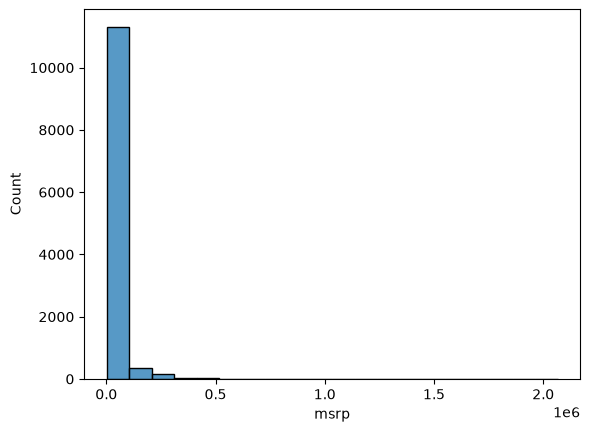

In [644]:
sns.histplot(df['msrp'], bins=20)

<Axes: xlabel='msrp', ylabel='Count'>

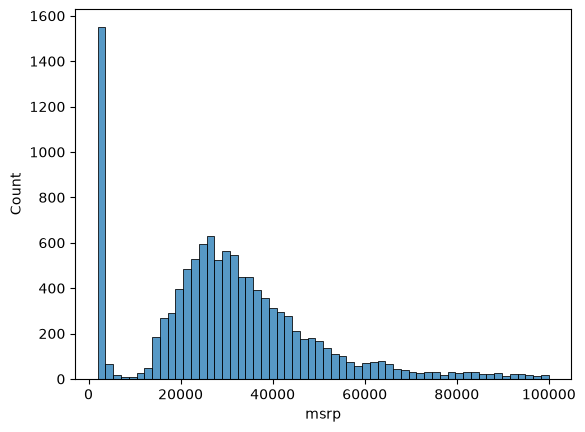

In [645]:
sns.histplot(df['msrp'][df['msrp'] < 100000])

In [646]:
np.log1p([0, 10, 100, 1000, 10000, 100000])

array([ 0.        ,  2.39789527,  4.61512052,  6.90875478,  9.21044037,
       11.51293546])

In [647]:
price_logs = np.log1p(df.msrp)

<Axes: xlabel='msrp', ylabel='Count'>

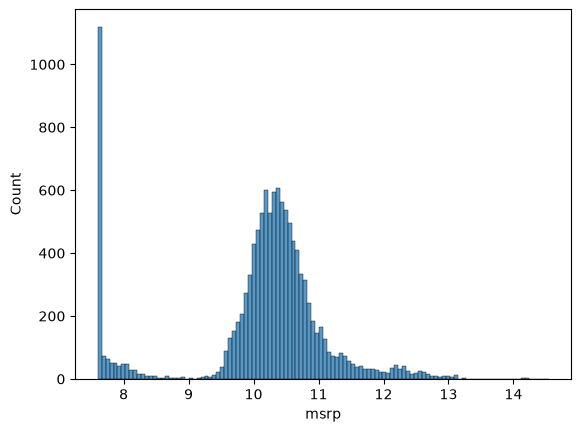

In [648]:
sns.histplot(price_logs)

In [649]:
df.isnull().sum()

make                    0
model                   0
year                    0
engine_fuel_type        3
engine_hp              69
engine_cylinders       30
transmission_type       0
driven_wheels           0
number_of_doors         6
market_category      3742
vehicle_size            0
vehicle_style           0
highway_mpg             0
city_mpg                0
popularity              0
msrp                    0
dtype: int64

In [650]:
seed = 2
df_train = df.sample(frac=0.6, random_state=seed)
df_val = df.sample(frac=0.2, random_state=seed)
df_test = df.sample(frac=0.2, random_state=seed)

In [651]:
y_train = np.log1p(df_train.msrp.values)
y_val = np.log1p(df_val.msrp.values)
y_test = np.log1p(df_test.msrp.values)

In [652]:
del df_train['msrp']
del df_val['msrp']
del df_test['msrp']

In [653]:
df_train.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity'],
      dtype='str')

In [654]:
display(len(df))
display(len(df_train))
display(len(df_val))
display(len(df_test))

11914

7148

2383

2383

In [655]:
df_train.iloc[10]

make                                 rolls-royce
model                     phantom_drophead_coupe
year                                        2015
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  453.0
engine_cylinders                            12.0
transmission_type                      automatic
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category        exotic,luxury,performance
vehicle_size                               large
vehicle_style                        convertible
highway_mpg                                   19
city_mpg                                      11
popularity                                    86
Name: 7557, dtype: object

### simple linear regression 

#### G(x) = y
#### w0 + w1.X1 + w2.X2 + ... = y

In [656]:
df.iloc[10]

make                                         bmw
model                                   1_series
year                                        2013
engine_fuel_type     premium_unleaded_(required)
engine_hp                                  300.0
engine_cylinders                             6.0
transmission_type                         manual
driven_wheels                   rear_wheel_drive
number_of_doors                              2.0
market_category          luxury,high-performance
vehicle_size                             compact
vehicle_style                              coupe
highway_mpg                                   28
city_mpg                                      20
popularity                                  3916
msrp                                       39600
Name: 10, dtype: object

In [657]:
xi = [453, 11, 86]

In [658]:
w0 = 7.17
W = [0.01, 0.04, 0.002]

In [659]:
def linear_regression(X):
    n = len(xi)
    pred = w0
    for j in range(n):
        pred += W[j]*xi[j]
    return pred

In [660]:
pred = linear_regression(xi)
result = np.expm1(pred)
round(float(result), 2)


222347.22

In [661]:
float(np.log1p(result))

12.312

### linear regression vector form

In [662]:
def dot(xi, W):
    n = len(xi)

    res = 0

    for j in range(n):
        res += xi[j]*W[j]
    
    return res
         

In [663]:
def linear_regression(xi, W):
    return w0 + dot(xi, W)


In [664]:
W_new = [w0] + W
W_new

[7.17, 0.01, 0.04, 0.002]

In [665]:

def linear_regression(xi, W):
    xi = [1] + xi

    return dot(xi, W_new)

In [666]:
linear_regression(xi, W)

12.312

In [667]:
x1 = [1, 148, 24, 1385]
x2 = [1, 132, 25, 2031]
x10 = [1, 453, 11, 86]

X = [x1, x2, x10]

X = np.array(X)
X.dot(W_new)

array([12.38 , 13.552, 12.312])

In [668]:
X_train = df_train[["engine_hp", "engine_cylinders", "popularity", "highway_mpg", "city_mpg"]].copy()

In [669]:
df_train.dtypes

make                     str
model                    str
year                   int64
engine_fuel_type         str
engine_hp            float64
engine_cylinders     float64
transmission_type        str
driven_wheels            str
number_of_doors      float64
market_category          str
vehicle_size             str
vehicle_style            str
highway_mpg            int64
city_mpg               int64
popularity             int64
dtype: object

In [670]:
X_train = X_train.fillna(0)
X_train.isnull().sum()

engine_hp           0
engine_cylinders    0
popularity          0
highway_mpg         0
city_mpg            0
dtype: int64

In [671]:
# n=len(X_train)
# ones = np.ones(n)

In [672]:
# X_train = np.column_stack([ones, X_train])

In [673]:
# XTX = X_train.T.dot(X_train)
# XTX

In [674]:
# XTX_inv = np.linalg.inv(XTX)
# XTX_inv

In [675]:
# XTX.dot(XTX_inv)

In [676]:
# XTX_inv.dot(X_train.T).dot(y_train)

In [677]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    W = XTX_inv.dot(X.T).dot(y)
    return W[0], W[1:]

In [678]:
w0, w = train_linear_regression(X_train, y_train)

In [679]:
y_pred = w0 + X_train.dot(w)


<Axes: ylabel='Count'>

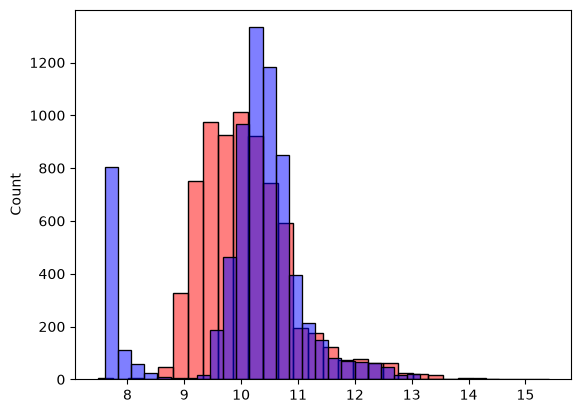

In [680]:
sns.histplot(y_pred, bins=30, alpha=0.5, color='red')
sns.histplot(y_train, bins=30, alpha=0.5, color='blue')

In [681]:
RSME = np.sqrt(((y_pred - y_train) ** 2).sum() / len(y_train))
RSME

np.float64(0.7554591756909307)

In [682]:
def rsme(y, y_pred):
    error = y - y_pred
    se = error ** 2
    mse = se.mean()
    return np.sqrt(mse)

In [683]:
rsme(y_train, y_pred)

np.float64(0.7554591756909307)

In [684]:
base = ["engine_hp", "engine_cylinders", "popularity", "highway_mpg", "city_mpg"]
X_train = df_train[base].copy()

In [685]:
X_val = df_val[base].copy()
X_val = X_val.fillna(0)
X_val.head()

,engine_hp,engine_cylinders,popularity,highway_mpg,city_mpg
2735,148.0,4.0,1385,33,24
6720,132.0,4.0,2031,32,25
5878,148.0,4.0,640,37,28
11190,90.0,4.0,873,18,16
4554,385.0,8.0,5657,21,15


In [686]:
y_pred = w0 + X_val.dot(w)

In [687]:
rsme(y_val, y_pred)

np.float64(0.7409838052519525)

In [688]:
X_val.values

array([[ 148.,    4., 1385.,   33.,   24.],
       [ 132.,    4., 2031.,   32.,   25.],
       [ 148.,    4.,  640.,   37.,   28.],
       ...,
       [ 302.,    6.,  617.,   28.,   20.],
       [ 210.,    6., 1851.,   20.,   16.],
       [ 122.,    4., 2009.,   31.,   27.]], shape=(2383, 5))

In [689]:
def prepare_data(df, base):
    X = df[base].copy()
    X = X.fillna(0)
    return X

In [690]:
X_train = prepare_data(df_train, base)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_data(df_val, base)
y_pred = w0 + X_val.dot(w)

rsme(y_val, y_pred)

np.float64(0.7409838052519525)

In [691]:
def prepare_data(df, base):
    df['age'] = 2017 - df['year']
    features = base + ['age']
    X = df[features].copy()
    X = X.fillna(0)
    return X

In [692]:
X_train = prepare_data(df_train, base)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_data(df_val, base)
y_pred = w0 + X_val.dot(w)

rsme(y_val, y_pred)

np.float64(0.5221985465407764)

<Axes: ylabel='Count'>

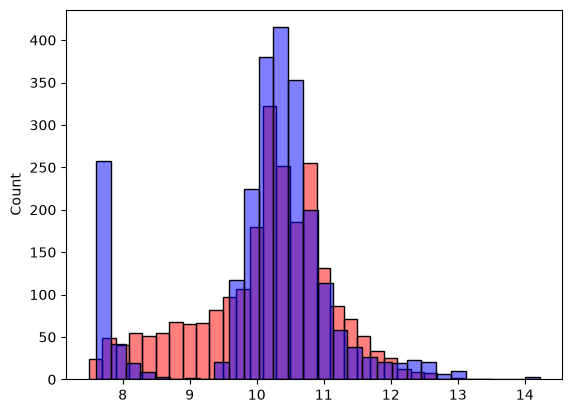

In [693]:
sns.histplot(y_pred, bins=30, alpha=0.5, color='red')
sns.histplot(y_val, bins=30, alpha=0.5, color='blue')

In [694]:
df_train = df_train.copy()
df_train['num_doors_2'] = (df_train.number_of_doors == 2).astype(int)
df_train['num_doors_3'] = (df_train.number_of_doors == 3).astype(int)
df_train['num_doors_4'] = (df_train.number_of_doors == 4).astype(int)
df_train


,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,age,num_doors_2,num_doors_3,num_doors_4
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,9,1,0,0
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,5,0,0,1
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,1,0,0,1
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,26,0,1,0
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11913,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,11,0,0,1
3602,cadillac,dts,2010,premium_unleaded_(recommended),275.0,8.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,23,15,1624,7,0,0,1
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,2,1,0,0
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,2,1,0,0


In [695]:
'num_doors_%s' % 4

'num_doors_4'

In [696]:
df_train = df_train.copy()
for d in [2, 3, 4]:

    df_train['num_doors_%s' % d] = (df_train.number_of_doors == d).astype(int)

In [697]:
df_train

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,age,num_doors_2,num_doors_3,num_doors_4
2735,chevrolet,cobalt,2008,regular_unleaded,148.0,4.0,manual,front_wheel_drive,2.0,NaN,compact,coupe,33,24,1385,9,1,0,0
6720,toyota,matrix,2012,regular_unleaded,132.0,4.0,automatic,front_wheel_drive,4.0,hatchback,compact,4dr_hatchback,32,25,2031,5,0,0,1
5878,subaru,impreza,2016,regular_unleaded,148.0,4.0,automatic,all_wheel_drive,4.0,hatchback,compact,4dr_hatchback,37,28,640,1,0,0,1
11190,volkswagen,vanagon,1991,regular_unleaded,90.0,4.0,manual,rear_wheel_drive,3.0,NaN,large,passenger_minivan,18,16,873,26,0,1,0
4554,ford,f-150,2017,flex-fuel_(unleaded/e85),385.0,8.0,automatic,four_wheel_drive,4.0,flex_fuel,large,crew_cab_pickup,21,15,5657,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11913,lincoln,zephyr,2006,regular_unleaded,221.0,6.0,automatic,front_wheel_drive,4.0,luxury,midsize,sedan,26,17,61,11,0,0,1
3602,cadillac,dts,2010,premium_unleaded_(recommended),275.0,8.0,automatic,front_wheel_drive,4.0,luxury,large,sedan,23,15,1624,7,0,0,1
434,bmw,4_series,2015,premium_unleaded_(required),300.0,6.0,automatic,rear_wheel_drive,2.0,"luxury,performance",midsize,convertible,31,20,3916,2,1,0,0
1902,volkswagen,beetle,2015,premium_unleaded_(recommended),210.0,4.0,automated_manual,front_wheel_drive,2.0,"hatchback,performance",compact,2dr_hatchback,30,24,873,2,1,0,0


In [698]:
def prepare_data(df, base):
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for d in [2, 3, 4]:

        df['num_doors_%s' % d] = (df.number_of_doors == d).astype(int)
        features.append('num_doors_%s' % d)

    X = df[features].copy()
    X = X.fillna(0)
    return X

In [699]:
X_train = prepare_data(df_train, base)
X_train

,engine_hp,engine_cylinders,popularity,highway_mpg,city_mpg,age,num_doors_2,num_doors_3,num_doors_4
2735,148.0,4.0,1385,33,24,9,1,0,0
6720,132.0,4.0,2031,32,25,5,0,0,1
5878,148.0,4.0,640,37,28,1,0,0,1
11190,90.0,4.0,873,18,16,26,0,1,0
4554,385.0,8.0,5657,21,15,0,0,0,1
...,...,...,...,...,...,...,...,...,...
11913,221.0,6.0,61,26,17,11,0,0,1
3602,275.0,8.0,1624,23,15,7,0,0,1
434,300.0,6.0,3916,31,20,2,1,0,0
1902,210.0,4.0,873,30,24,2,1,0,0


In [700]:
X_train = prepare_data(df_train, base)
w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_data(df_val, base)
y_pred = w0 + X_val.dot(w)

rsme(y_val, y_pred)

np.float64(0.520711406712512)

<Axes: ylabel='Count'>

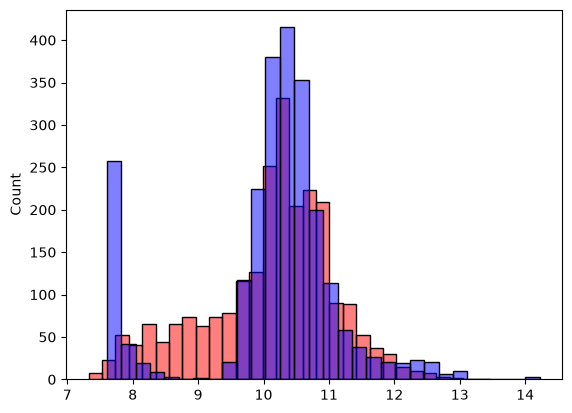

In [701]:
sns.histplot(y_pred, bins=30, alpha=0.5, color='red')
sns.histplot(y_val, bins=30, alpha=0.5, color='blue')

In [702]:
makes = list(df.make.value_counts().head().index)

In [703]:
def prepare_data(df, base):
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for d in [2, 3, 4]:

        df['num_doors_%s' % d] = (df.number_of_doors == d).astype(int)
        features.append('num_doors_%s' % d)

    for m in makes:

        df[f'make_{m}'] = (df.make == m).astype(int)
        features.append(f'make_{m}')

    X = df[features].copy()
    X = X.fillna(0)
    return X

In [704]:
X_train = prepare_data(df_train, base)

w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_data(df_val, base)
y_pred = w0 + X_val.dot(w)

rsme(y_val, y_pred)

np.float64(0.5096930125534269)

In [705]:
df.columns

Index(['make', 'model', 'year', 'engine_fuel_type', 'engine_hp',
       'engine_cylinders', 'transmission_type', 'driven_wheels',
       'number_of_doors', 'market_category', 'vehicle_size', 'vehicle_style',
       'highway_mpg', 'city_mpg', 'popularity', 'msrp'],
      dtype='str')

In [706]:
category_variables = [
    'make', 'engine_fuel_type', 'transmission_type', 'driven_wheels',
    'market_category', 'vehicle_size', 'vehicle_style',
]

In [707]:
categories = {}

for cat in category_variables:
    categories[cat] = list(df[cat].value_counts().head().index)

In [708]:
type(categories)

dict

In [709]:
categories

{'make': ['chevrolet', 'ford', 'volkswagen', 'toyota', 'dodge'],
 'engine_fuel_type': ['regular_unleaded',
  'premium_unleaded_(required)',
  'premium_unleaded_(recommended)',
  'flex-fuel_(unleaded/e85)',
  'diesel'],
 'transmission_type': ['automatic',
  'manual',
  'automated_manual',
  'direct_drive',
  'unknown'],
 'driven_wheels': ['front_wheel_drive',
  'rear_wheel_drive',
  'all_wheel_drive',
  'four_wheel_drive'],
 'market_category': ['crossover',
  'flex_fuel',
  'luxury',
  'luxury,performance',
  'hatchback'],
 'vehicle_size': ['compact', 'midsize', 'large'],
 'vehicle_style': ['sedan',
  '4dr_suv',
  'coupe',
  'convertible',
  '4dr_hatchback']}

In [710]:
def prepare_data(df, base):
    df['age'] = 2017 - df['year']
    features = base + ['age']

    for d in [2, 3, 4]:

        df['num_doors_%s' % d] = (df.number_of_doors == d).astype(int)
        features.append('num_doors_%s' % d)

    for key, values in categories.items():
        for v in values:

            df[f'{key}_{v}'] = (df[key] == v).astype(int)
            features.append(f'{key}_{v}')

    X = df[features].copy()
    X = X.fillna(0)
    return X

In [711]:
X_train = prepare_data(df_train, base)

w0, w = train_linear_regression(X_train, y_train)

X_val = prepare_data(df_val, base)
y_pred = w0 + X_val.dot(w)

rsme(y_val, y_pred)

np.float64(1798.0343581410825)

In [712]:
# XTX = [
#     [1, 2, 2],
#     [2, 1, 1.000001],
#     [2, 1.000001, 1],
# ]

# XTX = np.array(XTX)

In [713]:
# XTX = XTX + np.eye(3) * 0.01

In [714]:
# np.linalg.inv(XTX)

In [715]:
def train_linear_regression_reg(X, y, r=0.001):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + np.eye(XTX.shape[0]) * r
    XTX_inv = np.linalg.inv(XTX)
    W = XTX_inv.dot(X.T).dot(y)
    return W[0], W[1:]

In [716]:
X_train = prepare_data(df_train, base)

w0, w = train_linear_regression_reg(X_train, y_train, 0.001)

X_val = prepare_data(df_val, base)
y_pred = w0 + X_val.dot(w)

rsme(y_val, y_pred) 

np.float64(0.466563672008089)

In [717]:
for r in [0, 0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 10, 100]:
    X_train = prepare_data(df_train, base)

    w0, w = train_linear_regression_reg(X_train, y_train, r)

    X_val = prepare_data(df_val, base)
    y_pred = w0 + X_val.dot(w)
    
    res_val = rsme(y_val, y_pred) 

    print(f'The r is {r} and the rsme is {res_val}')

The r is 0 and the rsme is 1798.0343581410825
The r is 1e-05 and the rsme is 0.46656332430976577
The r is 0.0001 and the rsme is 0.4665633711191137
The r is 0.001 and the rsme is 0.466563672008089
The r is 0.01 and the rsme is 0.4665668550223225
The r is 0.1 and the rsme is 0.46661376384406444
The r is 1 and the rsme is 0.46768823995455727
The r is 10 and the rsme is 0.4807978831916641
The r is 100 and the rsme is 0.5808486429524762


In [722]:
df_full_train = pd.concat([df_train, df_val])
X_full_train = prepare_data(df_full_train, base)
y_full_train = np.concatenate([y_train, y_val])

In [724]:
# X_train = prepare_data(df_train, base)

w0, w = train_linear_regression_reg(X_full_train, y_full_train, 0.001)

X_test = prepare_data(df_test, base)
y_pred = w0 + X_test.dot(w)

rsme(y_test, y_pred) 

np.float64(0.4649399869434652)

In [727]:
car = df.iloc[10].to_dict()
car

{'make': 'bmw',
 'model': '1_series',
 'year': 2013,
 'engine_fuel_type': 'premium_unleaded_(required)',
 'engine_hp': 300.0,
 'engine_cylinders': 6.0,
 'transmission_type': 'manual',
 'driven_wheels': 'rear_wheel_drive',
 'number_of_doors': 2.0,
 'market_category': 'luxury,high-performance',
 'vehicle_size': 'compact',
 'vehicle_style': 'coupe',
 'highway_mpg': 28,
 'city_mpg': 20,
 'popularity': 3916,
 'msrp': 39600}

In [729]:
df_small = pd.DataFrame([car])
df_small

,make,model,year,engine_fuel_type,engine_hp,engine_cylinders,transmission_type,driven_wheels,number_of_doors,market_category,vehicle_size,vehicle_style,highway_mpg,city_mpg,popularity,msrp
0,bmw,1_series,2013,premium_unleaded_(required),300.0,6.0,manual,rear_wheel_drive,2.0,"luxury,high-performance",compact,coupe,28,20,3916,39600


In [731]:
X_small = prepare_data(df_small, base)

In [733]:
y_pred = w0 + X_small.dot(w)
y_pred

0    10.706088
dtype: float64

In [735]:
price = np.expm1(y_pred)
price

0    44625.719169
dtype: float64

In [736]:
price_real = np.expm1(y_test[10])
price_real

np.float64(479775.00000000006)